# Inference and Validation

In [1]:
import torch
from torchvision import datasets, transforms
from torch import nn, optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

In [9]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [2]:
# Define a transform to normalize the data
transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize((0.5,), (0.5,))])
# Download and load the training data
trainset = datasets.FashionMNIST('~/.pytorch/F_MNIST_data/', download=True, train=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)

# Download and load the test data
testset = datasets.FashionMNIST('~/.pytorch/F_MNIST_data/', download=True, train=False, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=True)

100%|██████████| 26.4M/26.4M [00:01<00:00, 17.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 266kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 4.96MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 19.3MB/s]


# Build the model

In [4]:
class MNISTFashionClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 10)

    def forward(self, x):
        # make sure input tensor is flattened
        x = x.view(x.shape[0], -1)

        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.log_softmax(self.fc4(x), dim=1)

        return x

The goal of validation is to measure the model's performance on data that isn't part of the training set.

In [5]:
# Create the model
model = MNISTFashionClassifier()

# Get the test data
images, labels = next(iter(testloader))

# Get the class probabilities
ps = torch.exp(model(images))

# Make sure the shape is appropriate, we should get 10 class probabilities for 64 examples
print(ps.shape)

torch.Size([64, 10])


With the probabilities, we can get the most likely class using the `ps.topk` method. This returns the $k$ highest values. Since we just want the most likely class, we can use `ps.topk(1)`. This returns a tuple of the top-$k$ values and the top-$k$ indices. If the highest value is the fifth element, we'll get back 4 as the index.

In [6]:
# Look at the most likely classes for the first 10 examples
top_p, top_class = ps.topk(1, dim=1)
print(top_class[:10, :])

tensor([[1],
        [9],
        [9],
        [9],
        [9],
        [1],
        [1],
        [9],
        [1],
        [1]])


Now we can check if the predicted classes match the labels. This is simple to do by equating `top_class` and `labels`, but we have to be careful of the shapes. Here `top_class` is a 2D tensor with shape `(64, 1)` while `labels` is 1D with shape `(64)`. To get the equality to work out the way we want, `top_class` and `labels` must have the same shape.

In [7]:
equals = top_class == labels.view(*top_class.shape)

In [8]:
# Calculate the percentage of correct predictions
accuracy = torch.mean(equals.type(torch.FloatTensor))
print(f'Accuracy: {accuracy.item()*100}%')

Accuracy: 10.9375%


The network is untrained so it's making random guesses and we should see an accuracy around 10%. Now let's train our network and include our validation pass so we can measure how well the network is performing on the test set. Since we're not updating our parameters in the validation pass, we can speed up the  by turning off gradients using `torch.no_grad()`:

```python
# turn off gradients
with torch.no_grad():
    # validation pass here
    for images, labels in testloader:
        ...
```

>**Exercise:** Implement the validation loop below. You can largely copy and paste the code from above, but I suggest typing it in because writing it out yourself is essential for building the skill. In general you'll always learn more by typing it rather than copy-pasting.

# Implementing the validation loop

In [12]:
model = MNISTFashionClassifier()                              # Create the model
criterion = nn.NLLLoss()                                        # Define the loss function
optimizer = optim.Adam(model.parameters(), lr=0.003)          # Define the optimizer

epochs = 30

train_losses, test_losses = [], []

for epoch in range(epochs):
  running_loss = 0

  for images, labels in trainloader:
    optimizer.zero_grad()

    log_ps = model(images)
    loss = criterion(log_ps, labels)
    loss.backward()
    optimizer.step()

    running_loss += loss.item()

  else:

    test_loss = 0
    accuracy = 0

    # Turn off gradients for validation (saves memory and computation)
    with torch.no_grad():
      for images, labels in testloader:
        log_ps = model(images)
        test_loss += criterion(log_ps, labels)

        ps = torch.exp(log_ps)
        top_p, top_class = ps.topk(1, dim=1)
        equals = top_class == labels.view(*top_class.shape)
        accuracy += torch.mean(equals.type(torch.FloatTensor))

    train_losses.append(running_loss/len(trainloader))
    test_losses.append(test_loss/len(testloader))

    print("Epoch: {}/{}.. ".format(epoch+1, epochs),
      "Training Loss: {:.3f}.. ".format(running_loss/len(trainloader)),
      "Test Loss: {:.3f}.. ".format(test_loss/len(testloader)),
      "Test Accuracy: {:.3f}".format(accuracy/len(testloader)))

Epoch: 1/30..  Training Loss: 0.509..  Test Loss: 0.442..  Test Accuracy: 0.842
Epoch: 2/30..  Training Loss: 0.390..  Test Loss: 0.421..  Test Accuracy: 0.847
Epoch: 3/30..  Training Loss: 0.355..  Test Loss: 0.400..  Test Accuracy: 0.860
Epoch: 4/30..  Training Loss: 0.334..  Test Loss: 0.384..  Test Accuracy: 0.862
Epoch: 5/30..  Training Loss: 0.318..  Test Loss: 0.372..  Test Accuracy: 0.869
Epoch: 6/30..  Training Loss: 0.301..  Test Loss: 0.382..  Test Accuracy: 0.867
Epoch: 7/30..  Training Loss: 0.293..  Test Loss: 0.358..  Test Accuracy: 0.873
Epoch: 8/30..  Training Loss: 0.285..  Test Loss: 0.378..  Test Accuracy: 0.867
Epoch: 9/30..  Training Loss: 0.273..  Test Loss: 0.364..  Test Accuracy: 0.870
Epoch: 10/30..  Training Loss: 0.269..  Test Loss: 0.407..  Test Accuracy: 0.867
Epoch: 11/30..  Training Loss: 0.261..  Test Loss: 0.367..  Test Accuracy: 0.878
Epoch: 12/30..  Training Loss: 0.255..  Test Loss: 0.401..  Test Accuracy: 0.866
Epoch: 13/30..  Training Loss: 0.249.

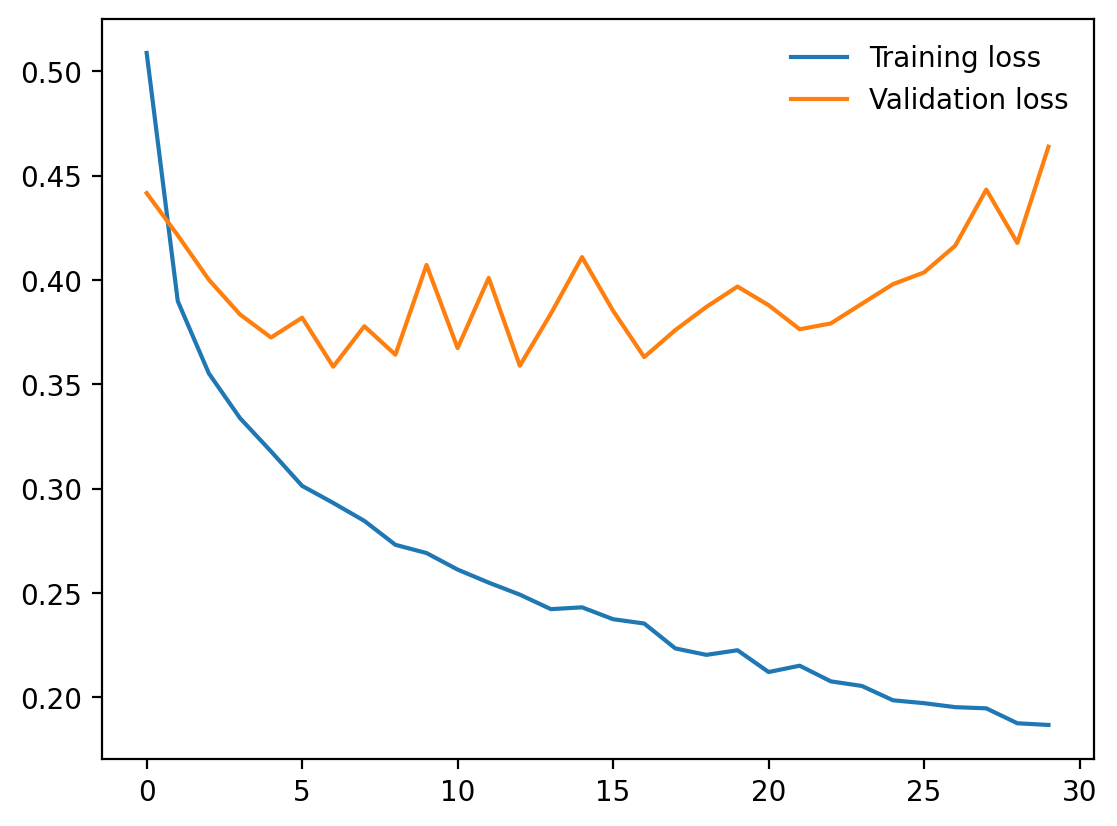

In [13]:
plt.plot(train_losses, label='Training loss')
plt.plot(test_losses, label='Validation loss')
plt.legend(frameon=False)

# Overfitting

If we look at the training and validation losses as we train the network, we can see a phenomenon known as overfitting.<br><br>
The network learns the training set better and better, resulting in lower training losses. However, it starts having problems generalizing to data outside the training set leading to the validation loss increasing. The ultimate goal of any deep learning model is to make predictions on new data, so we should strive to get the lowest validation loss possible. One option is to use the version of the model with the lowest validation loss, here the one around 8-10 training epochs. This strategy is called *early-stopping*. In practice, you'd save the model frequently as you're training then later choose the model with the lowest validation loss.

The most common method to reduce overfitting (outside of early-stopping) is *dropout*, where we randomly drop input units. This forces the network to share information between weights, increasing it's ability to generalize to new data. Adding dropout in PyTorch is straightforward using the [`nn.Dropout`](https://pytorch.org/docs/stable/nn.html#torch.nn.Dropout) module.

During training we want to use dropout to prevent overfitting, but during inference we want to use the entire network. So, we need to turn off dropout during validation, testing, and whenever we're using the network to make predictions. To do this, you use `model.eval()`. This sets the model to evaluation mode where the dropout probability is 0. You can turn dropout back on by setting the model to train mode with `model.train()`. In general, the pattern for the validation loop will look like this, where you turn off gradients, set the model to evaluation mode, calculate the validation loss and metric, then set the model back to train mode.

```python
# turn off gradients
with torch.no_grad():
    
    # set model to evaluation mode
    model.eval()
    
    # validation pass here
    for images, labels in testloader:
        ...

# set model back to train mode
model.train()
```

In [14]:
class MNISTFashionClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 256)
        self.fc2 = nn.Linear(256, 128)
        self.fc3 = nn.Linear(128, 64)
        self.fc4 = nn.Linear(64, 10)

        # Dropout module with 0.2 drop probability
        self.dropout = nn.Dropout(p=0.2)

    def forward(self, x):
        # make sure input tensor is flattened
        x = x.view(x.shape[0], -1)

        # Now with dropout
        x = self.dropout(F.relu(self.fc1(x)))
        x = self.dropout(F.relu(self.fc2(x)))
        x = self.dropout(F.relu(self.fc3(x)))

        # No dropout on the output layer
        x = F.log_softmax(self.fc4(x), dim=1)

        return x

In [15]:
model = MNISTFashionClassifier()
criterion = nn.NLLLoss()
optimizer = optim.Adam(model.parameters(), lr=0.003)

epochs = 30
steps = 0

train_losses, test_losses = [], []
for epoch in range(epochs):
    running_loss = 0

    for images, labels in trainloader:
        optimizer.zero_grad()

        log_ps = model(images)
        loss = criterion(log_ps, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    else:
        test_loss = 0
        accuracy = 0

        # Turn off gradients for validation (saves memory and computations)
        with torch.no_grad():
            model.eval()

            for images, labels in testloader:
                log_ps = model(images)
                test_loss += criterion(log_ps, labels)

                ps = torch.exp(log_ps)
                top_p, top_class = ps.topk(1, dim=1)
                equals = top_class == labels.view(*top_class.shape)
                accuracy += torch.mean(equals.type(torch.FloatTensor))

        model.train()

        train_losses.append(running_loss/len(trainloader))
        test_losses.append(test_loss/len(testloader))

        print("Epoch: {}/{}.. ".format(epoch+1, epochs),
              "Training Loss: {:.3f}.. ".format(running_loss/len(trainloader)),
              "Test Loss: {:.3f}.. ".format(test_loss/len(testloader)),
              "Test Accuracy: {:.3f}".format(accuracy/len(testloader)))

Epoch: 1/30..  Training Loss: 0.605..  Test Loss: 0.549..  Test Accuracy: 0.797
Epoch: 2/30..  Training Loss: 0.481..  Test Loss: 0.436..  Test Accuracy: 0.841
Epoch: 3/30..  Training Loss: 0.444..  Test Loss: 0.423..  Test Accuracy: 0.848
Epoch: 4/30..  Training Loss: 0.432..  Test Loss: 0.419..  Test Accuracy: 0.852
Epoch: 5/30..  Training Loss: 0.421..  Test Loss: 0.412..  Test Accuracy: 0.852
Epoch: 6/30..  Training Loss: 0.409..  Test Loss: 0.391..  Test Accuracy: 0.856
Epoch: 7/30..  Training Loss: 0.406..  Test Loss: 0.405..  Test Accuracy: 0.852
Epoch: 8/30..  Training Loss: 0.390..  Test Loss: 0.380..  Test Accuracy: 0.868
Epoch: 9/30..  Training Loss: 0.394..  Test Loss: 0.384..  Test Accuracy: 0.866
Epoch: 10/30..  Training Loss: 0.388..  Test Loss: 0.380..  Test Accuracy: 0.867
Epoch: 11/30..  Training Loss: 0.383..  Test Loss: 0.396..  Test Accuracy: 0.859
Epoch: 12/30..  Training Loss: 0.380..  Test Loss: 0.408..  Test Accuracy: 0.861
Epoch: 13/30..  Training Loss: 0.377.

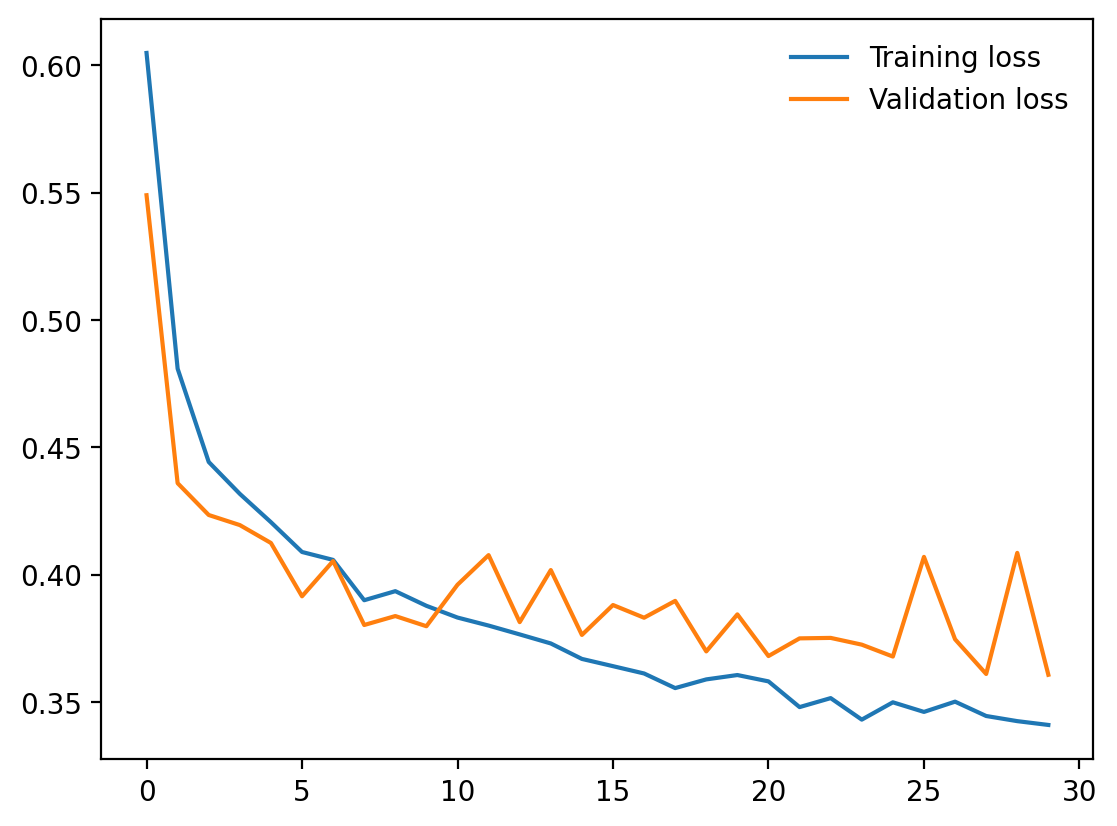

In [16]:
plt.plot(train_losses, label='Training loss')
plt.plot(test_losses, label='Validation loss')
plt.legend(frameon=False)

# Inference


Now that the model is trained, we can use it for inference. We've done this before, but now we need to remember to set the model in inference mode with `model.eval()`. You'll also want to turn off autograd with the `torch.no_grad()` context.

In [17]:
# Utility function
def view_classify(img, ps, version="MNIST"):
    ''' Function for viewing an image and it's predicted classes.
    '''
    ps = ps.data.numpy().squeeze()

    fig, (ax1, ax2) = plt.subplots(figsize=(6,9), ncols=2)
    ax1.imshow(img.resize_(1, 28, 28).numpy().squeeze())
    ax1.axis('off')
    ax2.barh(np.arange(10), ps)
    ax2.set_aspect(0.1)
    ax2.set_yticks(np.arange(10))
    if version == "MNIST":
        ax2.set_yticklabels(np.arange(10))
    elif version == "Fashion":
        ax2.set_yticklabels(['T-shirt/top',
                            'Trouser',
                            'Pullover',
                            'Dress',
                            'Coat',
                            'Sandal',
                            'Shirt',
                            'Sneaker',
                            'Bag',
                            'Ankle Boot'], size='small');
    ax2.set_title('Class Probability')
    ax2.set_xlim(0, 1.1)

    plt.tight_layout()

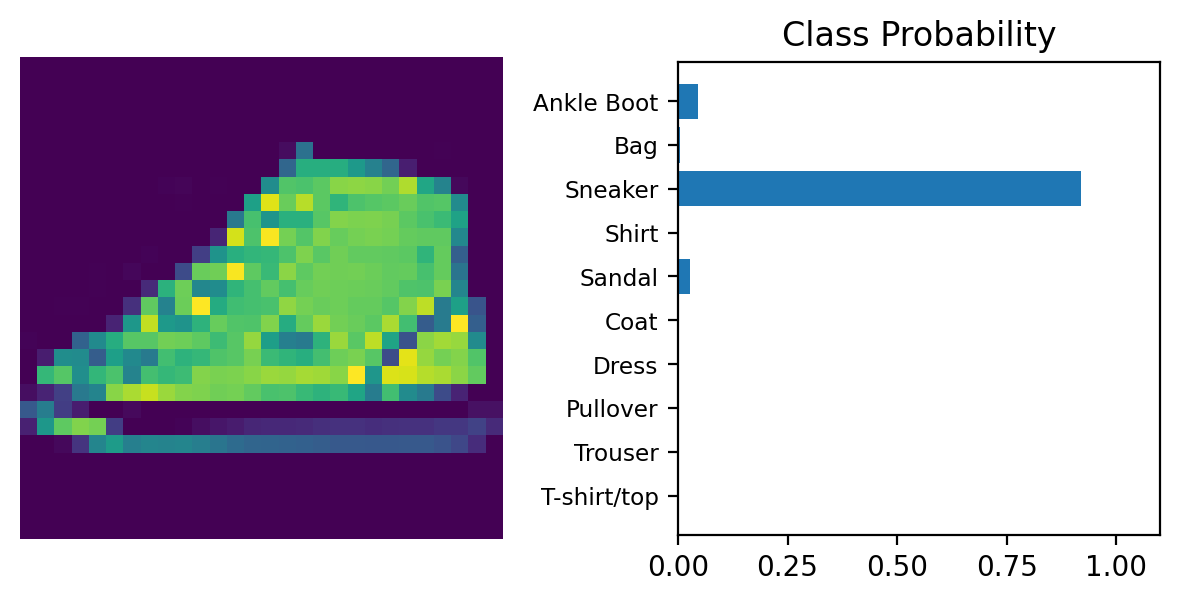

In [21]:
# Test our model
model.eval()

# Get the test data
dataiter = iter(testloader)
images, labels = next(dataiter)
test_img = images[0]

# Flatten the test image (convert from 2D to 1D)
test_img = test_img.view(test_img.shape[0], -1)

# Calculate the class probabilites for test_img
with torch.no_grad():
  output = model.forward(test_img)

ps = torch.exp(output)

# Plot the image and its probabilities
view_classify(test_img.view(1, 28, 28), ps, version="Fashion")